# Arbitrary Geometry

In [1]:
import meep as mp
from matplotlib import pyplot as plt
import numpy as np
import time

In [2]:
cell = mp.Vector3(10, 20, 0)
pml_layers = [mp.PML(1.0)]
resolution = 30

## Define a material function

The material function is placed in the material argument for a GeometricObject (eg. Block, Cylinder, etc.). <br>
> It can also be places in the simulation object, but it doesn't work when I try and there is no any examples for this. -> see "Test.ipynb"<br>

The material function can be any shapes, but is restricted by the range of the GeometricObject. <br>

Defining an function attribute "do_averaging" to be "True", it'll smoothing the material. <br>
> If you don't do the smoothing, the simulation might get wrong. But if you do, it will take a long time even for simple cases. -> see "donut_geom.ipynb" <br>
> Every GeometricObject is default to do the smoothing. <br>
> https://meep.readthedocs.io/en/latest/Subpixel_Smoothing/ <br>

### 1 Geometry Centers at (0,0,0)

For simplicity, our default center is (0,0,0) and setting the refractive index directly in the material function.

Problem:
- whiskers are not showing correctly (diagram and value) -> see "lines.ipynb" & "cat_geom_test.ipynb"

In [3]:
def cat_geom_1(position):

    # refractive index
    n = 1.5
    
    # eyes
    radius_min = 0.1; radius_max = 0.5
    polar_r_left = np.sqrt( (position.x-(-1))**2 + (position.y-(0))**2 )
    polar_r_right = np.sqrt( (position.x-(1))**2 + (position.y-(0))**2 )
    if radius_min <= polar_r_left <= radius_max:
        return mp.air
    if radius_min <= polar_r_right <= radius_max:
        return mp.air
    
    # mouth
    if (-0.25 <= position.x <= 0.25 and -1.5 <= position.y <= -1) and \
       (position.y <= 2*position.x-1 and position.y <= -2*position.x-1):
        return mp.air

    # whiskers
    if (2 <= position.x <= 3.5) and \
       (position.y == 0.5*position.x-2 or position.y == 0.3*position.x-2):
        return mp.Medium(index=n)
    if (-3.5 <= position.x <= -2) and \
       (position.y == -0.5*position.x-2 or position.y == -0.3*position.x-2):
        return mp.Medium(index=n)
    
    # face
    if (-3 <= position.x <= -2 and -2 <= position.y <= 4) and (position.y <= 6*position.x+16):
        return mp.Medium(index=n)
    if (2 <= position.x <= 3 and -2 <= position.y <= 4) and (position.y <= -6*position.x+16):
        return mp.Medium(index=n)
    if (-2 <= position.x <= -1 and 2 <= position.y <= 4) and (position.y <= -2*position.x):
        return mp.Medium(index=n)
    if (1 <= position.x <= 2 and 2 <= position.y <= 4) and (position.y <= 2*position.x):
        return mp.Medium(index=n)
    if (-2 <= position.x <= 2 and -2 <= position.y <= 2):
        return mp.Medium(index=n)

    # points that are not defined to any material are set to be air
    return mp.air

cat_geom_1.do_averaging = True    # subpixel smoothing

geometry_1 = []
geometry_1.append(mp.Block(center=mp.Vector3(),
                           size=cell,    # Set the GeometricObject has the same size as the cell
                           material=cat_geom_1))

     block, center = (0,0,0)
          size (10,20,0)
          axes (1,0,0), (0,1,0), (0,0,1)


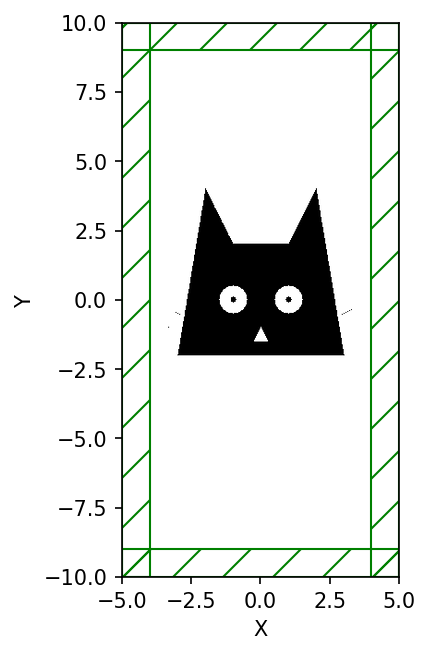

In [4]:
sim = mp.Simulation(cell_size=cell,
                    geometry=geometry_1,
                    resolution=resolution,
                    boundary_layers=pml_layers)

f = plt.figure(dpi=150)
sim.plot2D(ax=f.gca())
plt.show()

## Add a source

In [5]:
sources = [mp.Source(mp.ContinuousSource(frequency=0.15),
                     component=mp.Ez,
                     center=mp.Vector3(0,-7),
                     size=mp.Vector3(2,0,0))]

## Simulate

Let's see if the self-defined geometry works.

### No Subpixel Smoothing

Set the function attribute "do_averaging" of the material function to be "False"

In [6]:
cat_geom_1.do_averaging = False

     block, center = (0,0,0)
          size (10,20,0)
          axes (1,0,0), (0,1,0), (0,0,1)


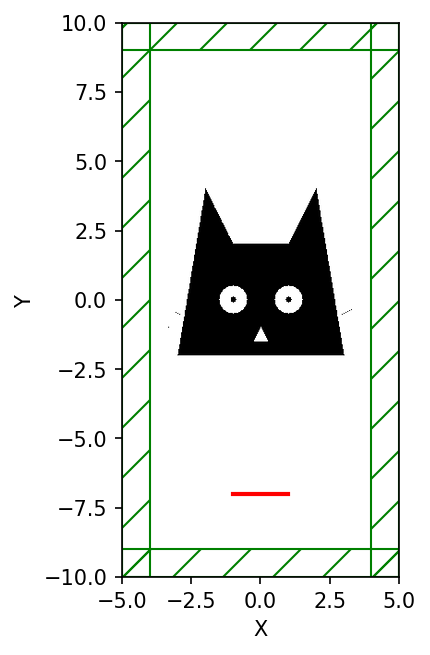

In [7]:
sim = mp.Simulation(cell_size=cell,
                    geometry=geometry_1,
                    resolution=resolution,
                    sources=sources,
                    boundary_layers=pml_layers)

f = plt.figure(dpi=150)
sim.plot2D(ax=f.gca())
plt.show()

In [8]:
start = time.time()
sim.run(until=100)
end = time.time()

time_no_smoothing = end - start
print(f"comsumed time: {time_no_smoothing} sec")

-----------
Initializing structure...
time for choose_chunkdivision = 0.000271082 s
Working in 2D dimensions.
Computational cell is 10 x 20 x 0 with resolution 30
     block, center = (0,0,0)
          size (10,20,0)
          axes (1,0,0), (0,1,0), (0,0,1)
time for set_epsilon = 5.00109 s
-----------


FloatProgress(value=0.0, description='0% done ')

run 0 finished at t = 100.0 (6000 timesteps)
comsumed time: 8.903704643249512 sec


     block, center = (0,0,0)
          size (10,20,0)
          axes (1,0,0), (0,1,0), (0,0,1)


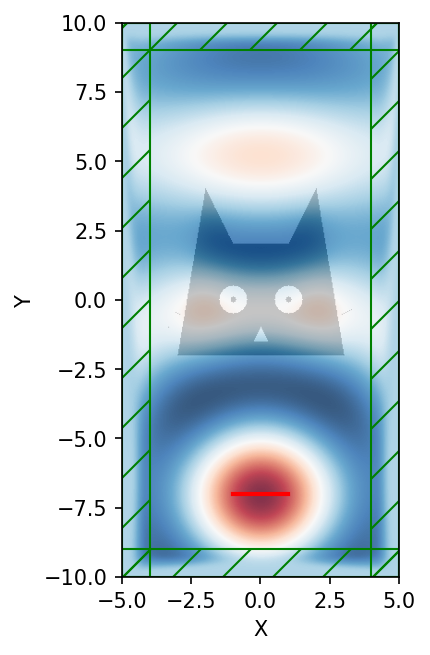

In [9]:
f = plt.figure(dpi=150)
sim.plot2D(fields=mp.Ez)
plt.show()

## Plot the Geometry by Using imshow()

Whiskers are hard to see and the dielectric constant are wrong.

<class 'numpy.ndarray'>
(300, 600)


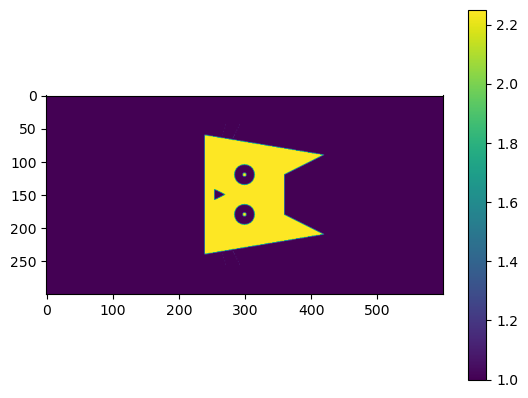

In [10]:
eps_data = sim.get_array(center=mp.Vector3(), size=cell, component=mp.Dielectric)
print(type(eps_data))
print(eps_data.shape)

plt.imshow(eps_data)
plt.colorbar()